In [ ]:

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc,
    precision_recall_curve
)

file_path = "/content/drive/MyDrive/Sreports_dse/dse_market_stress.csv"  # ✅ update path if needed
df = pd.read_csv(file_path)

FEATURE_COLS = [
    'daily_return', 'high_low_spread', 'intraday_volatility', 'volume_change_pct', 'price_gap',
    'rolling_5_day_volatility', 'rolling_10_day_momentum'
]
TARGET_COL = "market_type"

X = df[FEATURE_COLS].astype(np.float32)
y = df[TARGET_COL]

# Label encode target
le = LabelEncoder()
y = le.fit_transform(y).astype(np.int64)

print("Number of Infinite values in each column:\n", np.isinf(X).sum())
print("Number of NaN values in each column:\n", X.isna().sum())

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y[X.index]  # align labels after drop

Number of Infinite values in each column:
 daily_return                    0
high_low_spread                 0
intraday_volatility          1153
volume_change_pct           20614
price_gap                       0
rolling_5_day_volatility        0
rolling_10_day_momentum         0
dtype: int64
Number of NaN values in each column:
 daily_return                0
high_low_spread             0
intraday_volatility         0
volume_change_pct           0
price_gap                   0
rolling_5_day_volatility    0
rolling_10_day_momentum     0
dtype: int64


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

classes = np.unique(y_train).astype(int)


pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        multi_class="ovr",
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])


cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    "clf__C": [0.01, 0.1, 1.0, 10.0],
    "clf__solver": ["liblinear", "lbfgs"],
    "clf__penalty": ["l2"]  # keep stable across solvers
}

print("\nStarting GridSearchCV...\n")

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv3,
    n_jobs=-1,
    verbose=3,
    refit=True
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\nGrid Search Completed!")
print("Best Hyperparameters: ", grid.best_params_)
print("Best CV Accuracy: ", grid.best_score_)


Starting GridSearchCV...

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



Grid Search Completed!
Best Hyperparameters:  {'clf__C': 10.0, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Best CV Accuracy:  0.9967384562092262



===== Cross Validation Report (3-Fold) - Logistic Regression =====

accuracy: 0.9967 ± 0.0002
precision_macro: 0.9377 ± 0.0117
recall_macro: 0.8766 ± 0.0073
f1_macro: 0.9033 ± 0.0090
log_loss: 0.0372 ± 0.0014

Classification Report (Test Split):
               precision    recall  f1-score   support

           0     0.9979    0.9986    0.9983    161997
           1     0.9937    0.9935    0.9936     51969
           2     0.8203    0.6429    0.7208       504

    accuracy                         0.9965    214470
   macro avg     0.9373    0.8783    0.9042    214470
weighted avg     0.9964    0.9965    0.9965    214470



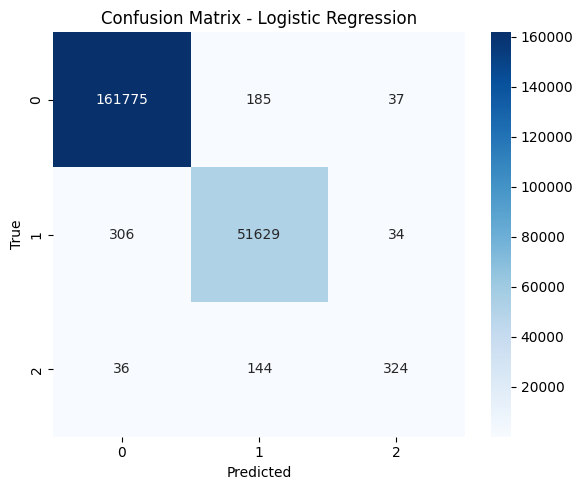

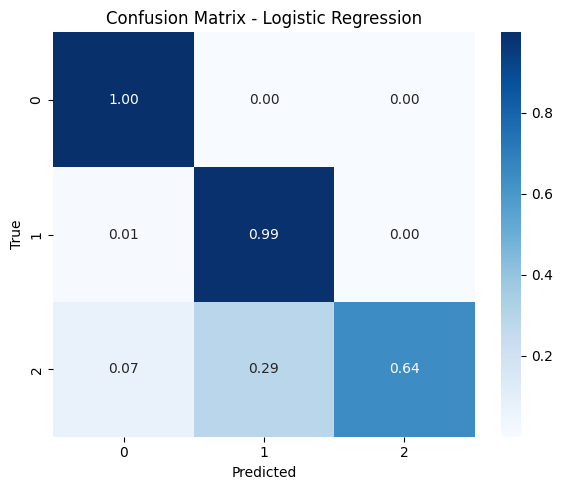

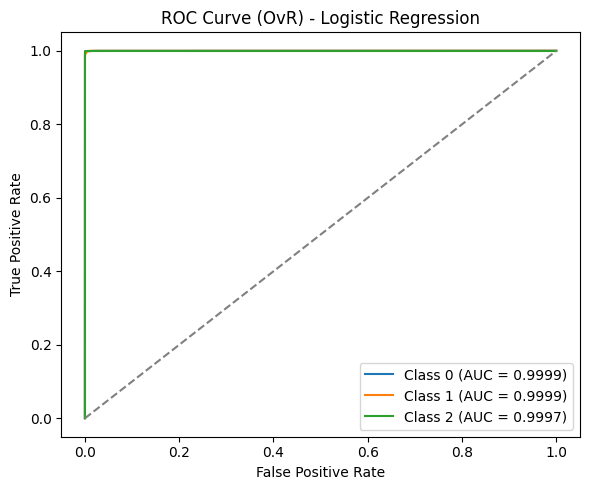

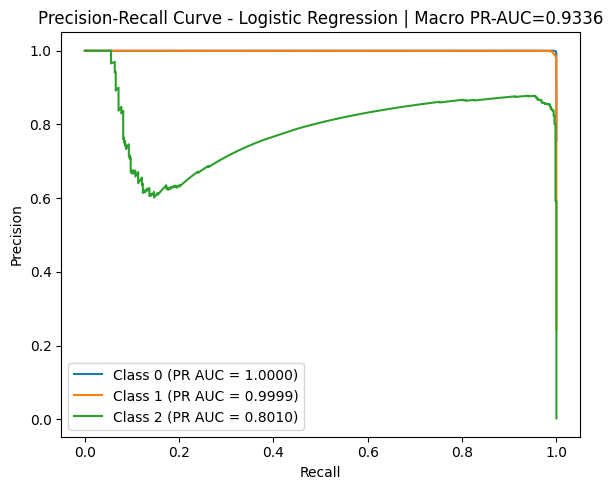

Per-class PR-AUC: {0: np.float64(0.9999582365046114), 1: np.float64(0.9998563098306078), 2: np.float64(0.8009977985870105)}
Macro PR-AUC: 0.9336041149740765


In [ ]:

scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'neg_log_loss']

cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=cv3,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

print("\n===== Cross Validation Report (3-Fold) - Logistic Regression =====\n")
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    if metric == "neg_log_loss":
        scores = -scores
        metric_name = "log_loss"
    else:
        metric_name = metric
    print(f"{metric_name}: {scores.mean():.4f} ± {scores.std():.4f}")


y_pred = best_model.predict(X_test)
print("\nClassification Report (Test Split):\n", classification_report(y_test, y_pred, digits=4))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


y_test_bin = label_binarize(y_test, classes=classes)
y_proba = best_model.predict_proba(X_test)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6, 5))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.title("ROC Curve (OvR) - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


pr_auc = {}
plt.figure(figsize=(6, 5))

for i in range(len(classes)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    pr_auc[i] = auc(recall, precision)
    plt.plot(recall, precision, label=f"Class {i} (PR AUC = {pr_auc[i]:.4f})")

macro_pr_auc = float(np.mean(list(pr_auc.values())))

plt.title(f"Precision-Recall Curve - Logistic Regression | Macro PR-AUC={macro_pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

print("Per-class PR-AUC:", pr_auc)
print("Macro PR-AUC:", macro_pr_auc)

In [ ]:

SAVE_DIR = "logistic_regression_dse_model"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(best_model, os.path.join(SAVE_DIR, "logistic_regression_model.pkl"))
joblib.dump(le, os.path.join(SAVE_DIR, "label_encoder.pkl"))

with open(os.path.join(SAVE_DIR, "feature_columns.json"), "w") as f:
    json.dump({"feature_columns": FEATURE_COLS}, f, indent=4)

best_params = {}
for k, v in grid.best_params_.items():
    best_params[str(k)] = v
with open(os.path.join(SAVE_DIR, "best_params.json"), "w") as f:
    json.dump(best_params, f, indent=4)

cv_summary = {}
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    if metric == "neg_log_loss":
        scores = -scores
        metric_name = "log_loss"
    else:
        metric_name = metric
    cv_summary[str(metric_name)] = {"mean": float(np.mean(scores)), "std": float(np.std(scores))}

with open(os.path.join(SAVE_DIR, "cv_results.json"), "w") as f:
    json.dump(cv_summary, f, indent=4)

class_mapping = {}
for cls_name, cls_id in zip(le.classes_, le.transform(le.classes_)):
    class_mapping[str(cls_name)] = int(cls_id)

metadata = {
    "model_type": "LogisticRegression (Pipeline: StandardScaler + LR)",
    "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset_shape": {
        "X_train": [int(X_train.shape[0]), int(X_train.shape[1])],
        "X_test":  [int(X_test.shape[0]),  int(X_test.shape[1])]
    },
    "class_mapping": class_mapping,
    "random_state": 42,
    "cv_folds": 3
}

with open(os.path.join(SAVE_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)

print(f"\n✅ Logistic Regression model package saved successfully in folder: {SAVE_DIR}")


✅ Logistic Regression model package saved successfully in folder: logistic_regression_dse_model
